Start of the Data Analytics Capstone Project

In [1]:
# Begin by importing modules I think I will need
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import cpi as cpi

# Filename variable in case I need it elsewhere and the name is long
filename = 'rotten_tomatoes_top_movies'

# Loading csv into initial dataframe
movies = pd.read_csv(f'{filename}.csv')

Data Inspection

In [2]:
movies

,Unnamed: 0,title,year,synopsis,critic_score,people_score,consensus,total_reviews,total_ratings,type,...,release_date_(theaters),release_date_(streaming),box_office_(gross_usa),runtime,production_co,sound_mix,aspect_ratio,view_the_collection,crew,link
0,0,Black Panther,2018,"After the death of his father, T'Challa return...",96,79.0,Black Panther elevates superhero cinema to thr...,519,"50,000+",Action & Adventure,...,"Feb 16, 2018 wide","May 2, 2018",$700.2M,2h 14m,Walt Disney Pictures,"DTS, Dolby Atmos",Scope (2.35:1),Marvel Cinematic Universe,"Chadwick Boseman, Michael B. Jordan, Lupita Ny...",http://www.rottentomatoes.com/m/black_panther_...
1,1,Avengers: Endgame,2019,"Adrift in space with no food or water, Tony St...",94,90.0,"Exciting, entertaining, and emotionally impact...",538,"50,000+",Action & Adventure,...,"Apr 26, 2019 wide","Jul 30, 2019",$858.4M,3h 1m,"Marvel Studios, Walt Disney Pictures","Dolby Atmos, DTS, Dolby Digital, SDDS",Scope (2.35:1),Marvel Cinematic Universe,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ...",http://www.rottentomatoes.com/m/avengers_endgame
2,2,Mission: Impossible -- Fallout,2018,Ethan Hunt and the IMF team join forces with C...,97,88.0,"Fast, sleek, and fun, Mission: Impossible - Fa...",433,"10,000+",Action & Adventure,...,"Jul 27, 2018 wide","Nov 20, 2018",$220.1M,2h 27m,"Bad Robot, Tom Cruise","DTS, Dolby Atmos, Dolby Digital",Scope (2.35:1),NaN,"Tom Cruise, Henry Cavill, Ving Rhames, Simon P...",http://www.rottentomatoes.com/m/mission_imposs...
3,3,Mad Max: Fury Road,2015,"Years after the collapse of civilization, the ...",97,86.0,With exhilarating action and a surprising amou...,427,"100,000+",Action & Adventure,...,"May 15, 2015 wide","Aug 10, 2016",$153.6M,2h,"Kennedy Miller Mitchell, Village Roadshow Pict...",Dolby Atmos,Scope (2.35:1),NaN,"Tom Hardy, Charlize Theron, Nicholas Hoult, Hu...",http://www.rottentomatoes.com/m/mad_max_fury_road
4,4,Spider-Man: Into the Spider-Verse,2018,"Bitten by a radioactive spider in the subway, ...",97,93.0,Spider-Man: Into the Spider-Verse matches bold...,387,"10,000+",Action & Adventure,...,"Dec 14, 2018 wide","Mar 7, 2019",$190.2M,1h 57m,"Lord Miller, Sony Pictures Animation, Pascal P...","Dolby Atmos, DTS, Dolby Digital, SDDS",Scope (2.35:1),NaN,"Shameik Moore, Hailee Steinfeld, Mahershala Al...",http://www.rottentomatoes.com/m/spider_man_int...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,1605,Priest,2011,In a society ravaged by centuries of war betwe...,15,46.0,"Sleek and stylish, but those qualities are was...",101,"50,000+",Western,...,"May 13, 2011 wide","Apr 16, 2012",$29.1M,1h 27m,"Michael De Luca, Stars Road Entertainment","SDDS, Dolby Digital",NaN,NaN,"Paul Bettany, Karl Urban, Cam Gigandet, Maggie...",http://www.rottentomatoes.com/m/10009274-priest
1606,1606,September Dawn,2006,In 1857 Capt. Alexander Fancher leads a wagon ...,16,49.0,"With its jarring editing, dull love story, and...",55,"5,000+",Western,...,"Jun 22, 2007 wide","Jan 1, 2008",$1.1M,1h 50m,"Voice Pictures Inc., September Dawn LLC",NaN,NaN,NaN,"Jon Voight, Trent Ford, Tamara Hope, Jon Gries...",http://www.rottentomatoes.com/m/september_dawn
1607,1607,American Outlaws,2001,"After the Civil War ends, Confederate soldiers...",14,68.0,"With corny dialogue, revisionist history, anac...",103,"25,000+",Western,...,"Aug 17, 2001 wide","Dec 1, 2017",$13.3M,1h 33m,Morgan Creek Productions,"Dolby Stereo, Dolby A, SDDS, DTS, Surround, Do...",Flat (1.85:1),NaN,"Colin Farrell, Scott Caan, Ali Larter, Gabriel...",http://www.rottentomatoes.com/m/american_outlaws
1608,1608,Jonah Hex,2010,"Having cheated death, gunslinger and bounty hu...",12,20.0,"Josh Brolin gives it his best shot, but he can...",152,"100,000+",Western,...,"Jun 18, 2010 wide","Mar 30, 2012",$10.5M,1h 21m,"Mad Chance, Weed Road Pictures",NaN,NaN,NaN,"Josh Brolin, John Malkovich, Megan Fox, Michae...",http://www.rottentomatoes.com/m/jonah_hex


In [3]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1610 non-null   int64  
 1   title                     1610 non-null   object 
 2   year                      1610 non-null   int64  
 3   synopsis                  1602 non-null   object 
 4   critic_score              1610 non-null   int64  
 5   people_score              1609 non-null   float64
 6   consensus                 1593 non-null   object 
 7   total_reviews             1610 non-null   int64  
 8   total_ratings             1610 non-null   object 
 9   type                      1610 non-null   object 
 10  rating                    1139 non-null   object 
 11  genre                     1603 non-null   object 
 12  original_language         1570 non-null   object 
 13  director                  1609 non-null   object 
 14  producer

In [4]:
columns_to_drop = ['total_reviews', 'total_ratings', 'rating', 'original_language','runtime', 'sound_mix', 'aspect_ratio', 'view_the_collection', 'crew', 'link']
movies.drop(columns=columns_to_drop, inplace=True)

In [5]:
movies.rename(columns={'Unnamed: 0': 'movie#', 'release_date_(theaters)': 'theater_release', 'release_date_(streaming)': 'streaming_release', 'box_office_(gross_usa)': 'box_office_gross'}, inplace=True)

In [6]:
movies_null = movies[movies['box_office_gross'].isnull()]
movies_null

,movie#,title,year,synopsis,critic_score,people_score,consensus,type,genre,director,producer,writer,theater_release,streaming_release,box_office_gross,production_co
12,12,The Adventures of Robin Hood,1938,"When King Richard the Lionheart is captured, h...",100,89.0,Errol Flynn thrills as the legendary title cha...,Action & Adventure,"action, adventure","Michael Curtiz, William Keighley",Hal B. Wallis,"Norman Reilly Raine, Seton I. Miller","Feb 11, 1938 wide","Jan 23, 2014",NaN,"Warner Brothers, First National Pictures"
13,13,King Kong,1933,Actress Ann Darrow (Fay Wray) and director Car...,98,86.0,King Kong explores the soul of a monster -- ma...,Action & Adventure,"adventure, fantasy","Merian C. Cooper, Ernest B. Schoedsack","Merian C. Cooper, Ernest B. Schoedsack","James Ashmore Creelman, Ruth Rose",NaN,"Nov 28, 2008",NaN,RKO Radio Pictures Inc.
16,16,Zootopia,2016,From the largest elephant to the smallest shre...,98,92.0,The brilliantly well-rounded Zootopia offers a...,Action & Adventure,"kids and family, comedy, adventure, animation","Byron Howard, Rich Moore",Clark Spencer,"Jared Bush, Phil Johnston","Mar 4, 2016 wide","Jun 7, 2016",NaN,Walt Disney Animation Studios
23,23,Up,2009,"Carl Fredricksen (Ed Asner), a 78-year-old bal...",98,90.0,"An exciting, funny, and poignant adventure, Up...",Action & Adventure,"adventure, kids and family, animation, comedy","Pete Docter, Bob Peterson",Jonas Rivera,"Bob Peterson, Pete Docter","May 29, 2009 wide","Nov 21, 2015",NaN,Pixar Animation Studios
26,26,The Treasure of the Sierra Madre,1948,"In this classic adventure film, two rough-and-...",100,93.0,"Remade but never duplicated, this darkly humor...",Action & Adventure,"western, adventure, drama",John Huston,Henry Blanke,NaN,NaN,"May 8, 2015",NaN,Warner Brothers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1578,1578,The Salvation,2014,"After shooting the man who murdered his wife, ...",73,62.0,It's all but impossible to add anything new or...,Western,"drama, western",Kristian Levring,"Michael Auret, Tracy Brimm, Marlow De Mardt, S...","Anders Thomas Jensen, Kristian Levring","Feb 27, 2015 limited","Nov 30, 2016",NaN,"Zentropa Entertainments, Spier Films, Forward ..."
1584,1584,Heaven's Gate,1980,Harvard graduate James Averill (Kris Kristoffe...,59,54.0,Heaven's Gate contains too many ideas and stri...,Western,"western, history, drama",Michael Cimino,Joann Carelli,Michael Cimino,"Apr 23, 1981 wide","Jan 8, 2017",NaN,"United Artists, Partisan Productions"
1593,1593,The Pale Door,2020,"After a botched train robbery, two brothers le...",50,66.0,Beyond The Pale Door lies an intriguing wester...,Western,"western, horror",Aaron B. Koontz,"Cameron Burns, Roman Dent, Aaron B. Koontz, Ja...",Aaron B. Koontz,"Aug 21, 2020 limited","Aug 21, 2020",NaN,"Title Media, Paper Street Pictures, BondIt Med..."
1595,1595,Brimstone,2016,A frontier woman turns fugitive when she is wr...,43,53.0,NaN,Western,"mystery and thriller, western",Martin Koolhoven,NaN,Martin Koolhoven,"Mar 10, 2017 limited","Apr 11, 2017",NaN,"FilmWave, N279 Entertainment, Prime Time"


In [7]:
# Removing duplicate rows by assigning the rows a primary type, and removing all subsequent rows with the same movie name
type_mapping = {
    'Action & Adventure': 'Action',
    'Animation': 'Family',
    'Art House & International': 'Drama',
    'Classics': 'Drama',
    'Comedy': 'Comedy',
    'Documentary': 'Documentary',
    'Drama': 'Drama',
    'Horror': 'Horror',
    'Kids & Family': 'Family',
    'Musical & Performing Arts': 'Musical',
    'Mystery & Suspense': 'Thriller',
    'Romance': 'Romance',
    'Science Fiction & Fantasy': 'Sci-Fi',
    'Special Interest': 'Documentary',
    'Sports & Fitness': 'Sports',
    'Television': 'Drama',
    'Western': 'Western'
}
# Map the original types to the new ones
movies['type'] = movies['type'].map(type_mapping)

# Sort by original index to preserve the original order
movies.sort_values(['movie#'], inplace=True)

# Drop duplicates, keepin ghte first occurrence
movies = movies.drop_duplicates(subset=['title', 'year'], keep='first')

In [8]:
# Removing rows with null values so that the calculations below are more accurate and not skewed. 
movies = movies[movies['box_office_gross'].notnull()].copy()
movies = movies[movies['people_score'].notnull()].copy()

# Gone with the Wind is an extreme outlier that is being omitted. It's inflation adjusted gross is 3x higher than the next highest grossing film. 
movies = movies[movies['title'] != 'Gone With the Wind']

In [9]:
movies['critic_score'] = movies['critic_score'].astype(float)
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 695 entries, 0 to 1609
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   movie#             695 non-null    int64  
 1   title              695 non-null    object 
 2   year               695 non-null    int64  
 3   synopsis           695 non-null    object 
 4   critic_score       695 non-null    float64
 5   people_score       695 non-null    float64
 6   consensus          686 non-null    object 
 7   type               695 non-null    object 
 8   genre              695 non-null    object 
 9   director           695 non-null    object 
 10  producer           652 non-null    object 
 11  writer             561 non-null    object 
 12  theater_release    530 non-null    object 
 13  streaming_release  690 non-null    object 
 14  box_office_gross   695 non-null    object 
 15  production_co      633 non-null    object 
dtypes: float64(2), int64(2), objec

In [10]:
movies['score_differential'] = movies['critic_score'] - movies['people_score']

In [ ]:
# Remove $ and commas
movies['box_office_gross'] = movies['box_office_gross'].astype(str).str.replace(r'[\$,]', '', regex=True)

# Extract numeric part and optional M/K suffix
extracted = movies['box_office_gross'].str.extract(r'(?P<num>[\d\.]+)(?P<suffix>[MK]?)')

# Convert numeric part to float
movies['box_office_gross'] = pd.to_numeric(extracted['num'], errors='coerce')

# Apply multiplier based on suffix
multiplier = extracted['suffix'].map({'M': 1_000_000, 'K': 1_000}).fillna(1)
movies['box_office_gross'] *= multiplier

# Replace any remaining NaN with 0
movies['box_office_gross'] = movies['box_office_gross'].fillna(0)

# Creating an inflation-adjusted column for better comparisons across time periods.
# Build a multiplier map for each unique year in the dataset
cpi.update()  # Update CPI data to ensure it's current
year_multipliers = {
    int(year): cpi.inflate(1, int(year), to=2024)
    for year in movies['year'].dropna().unique()
}

# Map multipliers to each row and multiply
movies['box_office_gross_inflation_adjusted'] = (
    movies['box_office_gross'] * movies['year'].map(year_multipliers)
)


The CPI module is used to bring the outdated box office gross figures more in line with modern dollar amounts due to inflation. The year 2024 is chosen here since that is the latest release date of a movie contained within the dataset. The multiplier is assigned to a variable, then applied to every movie who's release date corresponds with that year value. 

In [12]:
movies['box_office_gross'].map('{:,.1f}'.format).unique()

array(['700,200,000.0', '858,400,000.0', '220,100,000.0', '153,600,000.0',
       '190,200,000.0', '412,800,000.0', '188,000,000.0', '210,500,000.0',
       '315,000,000.0', '226,300,000.0', '620,200,000.0', '123.0',
       '390,700,000.0', '608,600,000.0', '146,800,000.0', '334,400,000.0',
       '107,800,000.0', '271,700.0', '1,200,000.0', '260,900,000.0',
       '140,400,000.0', '2,000,000.0', '91,500,000.0', '408,100,000.0',
       '364,000,000.0', '381,000,000.0', '304,400,000.0', '6,000,000.0',
       '78,800,000.0', '15,700,000.0', '257,800,000.0', '257,700,000.0',
       '248,800,000.0', '678,800,000.0', '216,600,000.0', '345.0',
       '31,900,000.0', '333,700,000.0', '48,000,000.0', '318,300,000.0',
       '5,200,000.0', '171,000,000.0', '232,600,000.0', '77,600,000.0',
       '291,900,000.0', '233,900,000.0', '6,300,000.0', '175,700,000.0',
       '26,900,000.0', '66,300,000.0', '258,400.0', '167,000,000.0',
       '389,800,000.0', '20,500,000.0', '74,300,000.0', '208,500,00

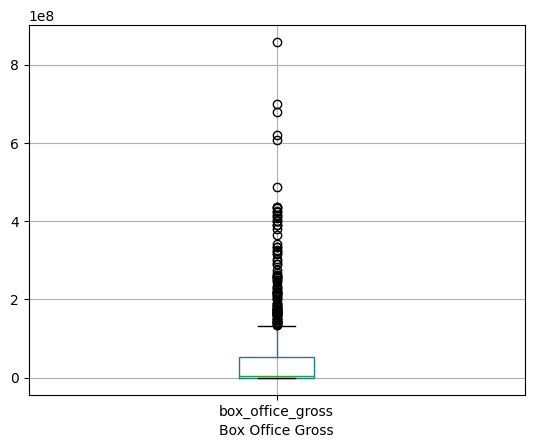

In [13]:
plt.figure()
movies.boxplot('box_office_gross')
plt.xlabel('Box Office Gross')
plt.show()

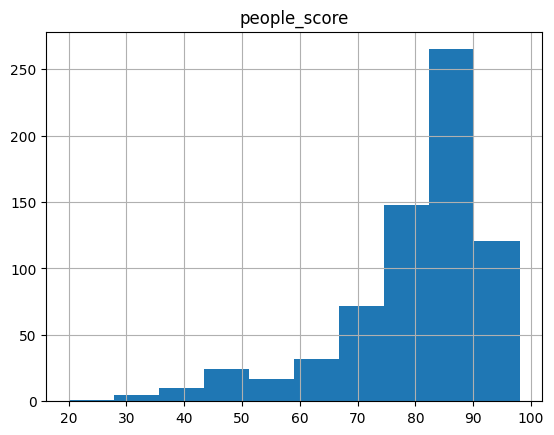

In [14]:
movies.hist('people_score', bins=10)
plt.show()


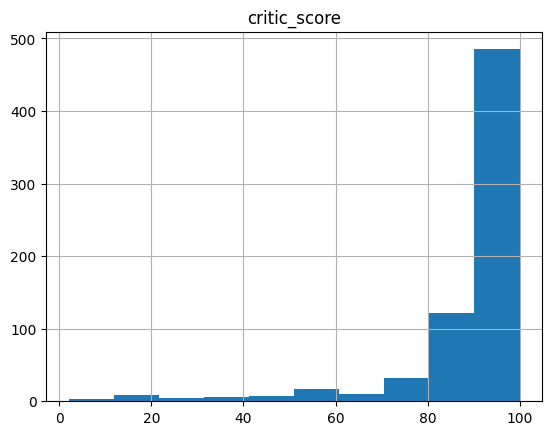

In [15]:
movies.hist('critic_score', bins=10)
plt.show()


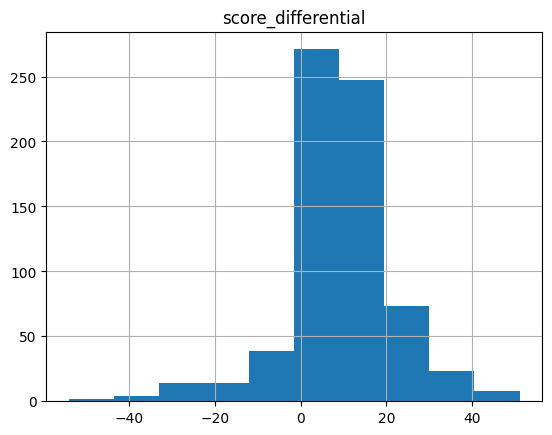

In [16]:
movies.hist('score_differential', bins=10)
plt.show()

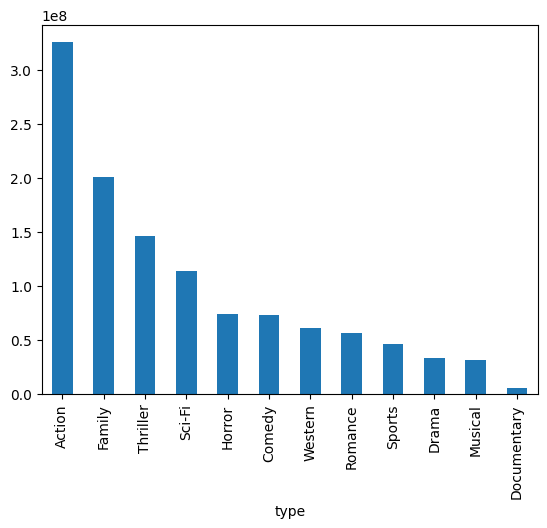

In [17]:
type_grouped_movies = movies.groupby('type')
sorted_means = type_grouped_movies['box_office_gross_inflation_adjusted'].mean().sort_values(ascending=False)
sorted_means.plot(kind='bar', orientation='vertical')
plt.show()

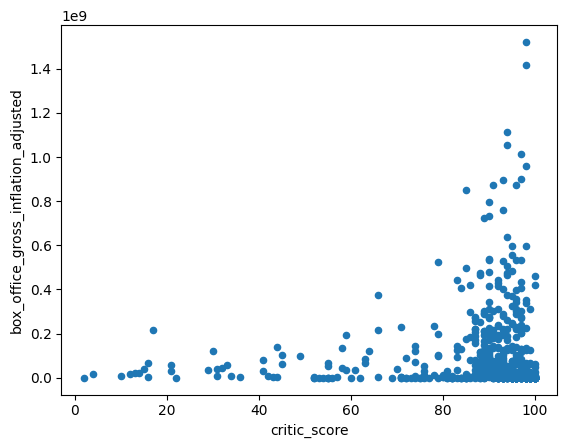

In [18]:
movies.plot(kind='scatter', x='critic_score', y='box_office_gross_inflation_adjusted')
plt.show()

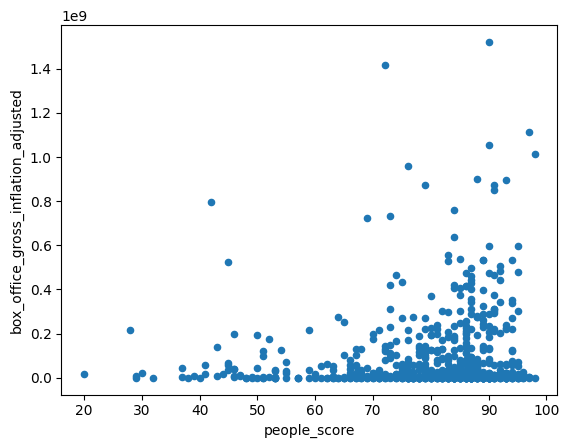

In [19]:
movies.plot(kind='scatter', x='people_score', y='box_office_gross_inflation_adjusted')
plt.show()

In [20]:
movies.to_csv(f'{filename}_cleaned.csv', index=False)

In [21]:
# Spearman
movies[['critic_score', 'people_score', 'box_office_gross_inflation_adjusted']].corr(method='spearman')

,critic_score,people_score,box_office_gross_inflation_adjusted
critic_score,1.000000,0.478564,-0.234529
people_score,0.478564,1.000000,0.060231
box_office_gross_inflation_adjusted,-0.234529,0.060231,1.000000


In [22]:
# Pearson
movies[['critic_score', 'people_score', 'box_office_gross_inflation_adjusted']].corr()

,critic_score,people_score,box_office_gross_inflation_adjusted
critic_score,1.000000,0.655868,0.047937
people_score,0.655868,1.000000,0.096953
box_office_gross_inflation_adjusted,0.047937,0.096953,1.000000
